Visualisierung - Diabetes Datensatz

Explorative Datenanalyse mit bereinigten Daten aus der zweiten Einsendeaufgabe

## Setup

In [1]:
#Importieren der benötigten Bibliotheken und Setup des Stils in Übereinstimmung mit der Übungsaufgabe
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)



In [2]:
# Laden der bereinigten Daten und Darstellung des Tabellenkopfes
df = pd.read_csv('diabetesdata_cleaned.csv')
print(f"Geladen: {df.shape}")
display(df.head(5))

# Erstellung eines Ordners für die Figuren, falls dieser noch nicht existiert
os.makedirs("figures", exist_ok=True)

Geladen: (761, 10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Adipositas,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,adipositas_grade_I,0.627,50,1
1,1,85,66,29,125,26.6,praeadipositas,0.351,31,0
2,8,183,64,29,125,23.3,normalgewichtig,0.672,32,1
3,1,89,66,23,94,28.1,praeadipositas,0.167,21,0
4,0,137,40,35,168,43.1,adipositas_grade_III,2.288,33,1


Gearbeitet wird mit dem bereinigten Datensatz aus der vorherigen Einsendesaufgabe. Zuvor wurde anhand der Kommentare die Korrektur der NaN-Werte nicht mittels Interpolation, sondern durch Ersetzen mit dem Median der jeweiligen Spalte vorgenommen. Der Datensatz enthält medizinische Daten von 761 weiblichen Patientinnen aus der Pima Bevölkerung. Neben dem Outcome (Diabetes ja (1)/nein (0)) sind
Parameter wie Glukose, Blutdruck, BMI und Alter enthalten.

## Altersverteilung

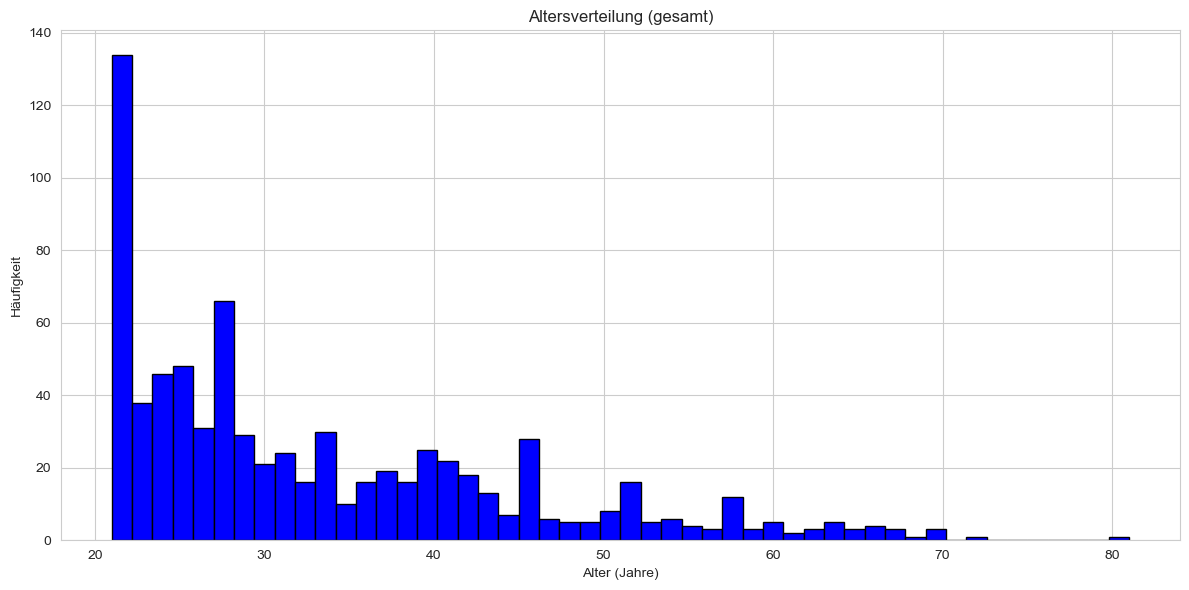

In [3]:
# Plot: Altersverteilung gesamt

plt.hist(df['Age'], bins=50, color='blue', edgecolor='black')
plt.xlabel('Alter (Jahre)')
plt.ylabel('Häufigkeit')
plt.title('Altersverteilung (gesamt)')


plt.tight_layout()
plt.savefig("figures/alter_verteilung.png", dpi=300, bbox_inches="tight")
plt.show()


Plot der Altersdarstellung zur Übersicht. Die meisten Patientinnen sind jung (20–30 Jahre).


## Verteilung der Zielvariable Diabetes-Diagnose

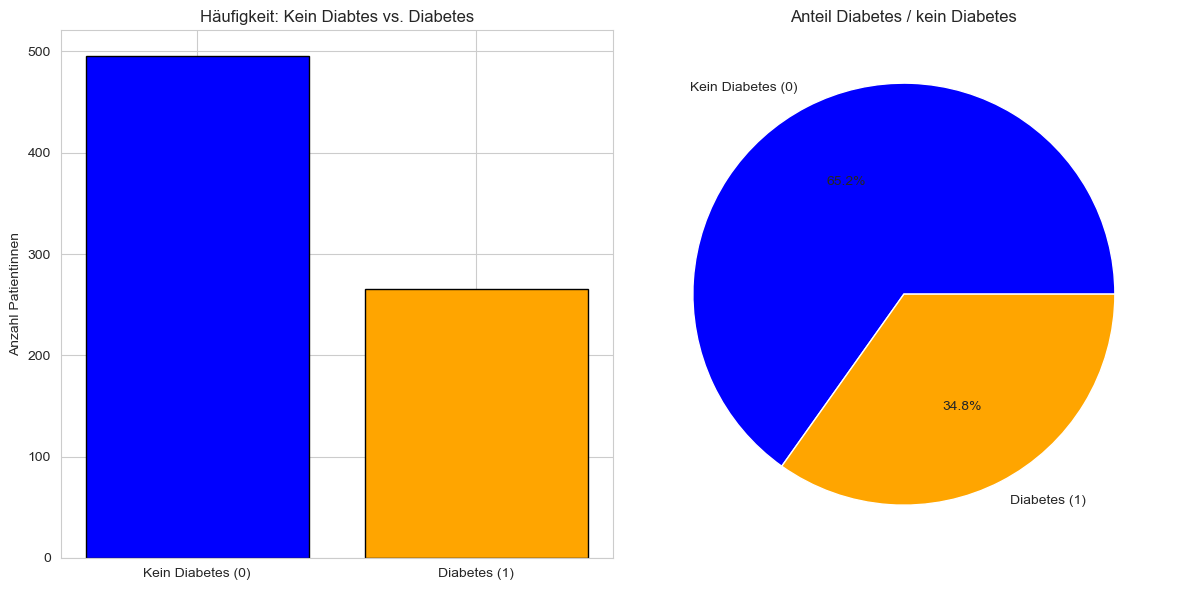

Kein Diabetes: 496 (65.2%)
Diabetes: 265 (34.8%)


In [4]:


fig, ax = plt.subplots(1, 2)

# Plot 1: Balkendiagramm
counts = df['Outcome'].value_counts()
labels = ['Kein Diabetes (0)', 'Diabetes (1)']
ax[0].bar(labels, counts.values, color=['blue', 'orange'], edgecolor='black')
ax[0].set_ylabel('Anzahl Patientinnen')
ax[0].set_title('Häufigkeit: Kein Diabtes vs. Diabetes')


# Plot 2: Pie Chart
ax[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=['blue', 'orange'])
ax[1].set_title('Anteil Diabetes / kein Diabetes')

plt.tight_layout()
fig.savefig("figures/outcome_verteilung.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Kein Diabetes: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Diabetes: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

Dargestellt ist ein Histogram sowie ein Pie Chart zur initialen Darstellung des Outcomes. Ca. 65% der Patientinnen haben keinen Diabetes, 35% sind positiv diagnostiziert. Der Datensatz ist also nicht gleich-verteilt.
Das Balkendiagramm zeigt die absoluten Zahlen, das Pie Chart die prozentualen Anteile.


## Glukoseverteilung

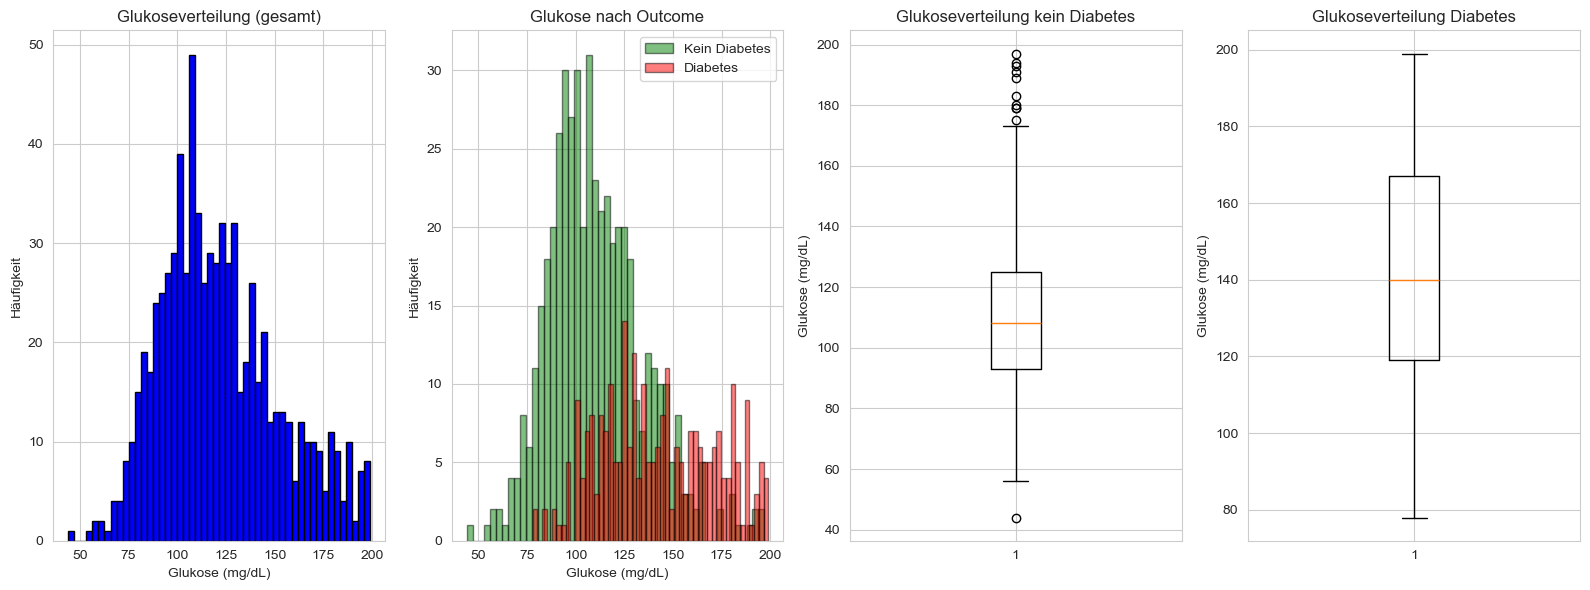

Durchschnitt Glukose (kein Diabetes): 110.8 mg/dL
Durchschnitt Glukose (Diabetes):      142.1 mg/dL


In [5]:
fig, ax = plt.subplots(1, 4, figsize=(16, 6))

# Plot 1: Gesamtverteilung
ax[0].hist(df['Glucose'], bins=50, color='blue', edgecolor='black')
ax[0].set_xlabel('Glukose (mg/dL)')
ax[0].set_ylabel('Häufigkeit')
ax[0].set_title('Glukoseverteilung (gesamt)')


# Plot 2: Getrennt nach Outcome
df[df['Outcome'] == 0]['Glucose'].hist(ax=ax[1], bins=50, color='green', alpha=0.5,edgecolor='black', label='Kein Diabetes')
df[df['Outcome'] == 1]['Glucose'].hist(ax=ax[1], bins=50, color='red',alpha=0.5, edgecolor='black', label='Diabetes')
ax[1].set_xlabel('Glukose (mg/dL)')
ax[1].set_ylabel('Häufigkeit')
ax[1].set_title('Glukose nach Outcome')
ax[1].legend()

# Plot 3: Boxplot
gruppe0 = df[df['Outcome'] == 0]['Glucose']
gruppe1 = df[df['Outcome'] == 1]['Glucose']

ax[2].boxplot(gruppe0)
ax[2].set_title('Glukoseverteilung kein Diabetes')
ax[2].set_ylabel('Glukose (mg/dL)')

ax[3].boxplot(gruppe1)
ax[3].set_title('Glukoseverteilung Diabetes')
ax[3].set_ylabel('Glukose (mg/dL)')


plt.tight_layout()
fig.savefig("figures/glukose_verteilung.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Durchschnitt Glukose (kein Diabetes): {df[df['Outcome']==0]['Glucose'].mean():.1f} mg/dL")
print(f"Durchschnitt Glukose (Diabetes):      {df[df['Outcome']==1]['Glucose'].mean():.1f} mg/dL")

Dargestellt sind zwei Histogramme der Glukoseverteilung insgesamt bzw. anhand des Outcomes sowie die jeweiligen Boxplots. Man erkennt, dass Serum-Glukose ein Prädiktor für Diabetes ist. Im Histogramm ist zu sehen, dass Patientinnen mit Diabetes im Schnitt deutlich höhere Glukosewerte aufweisen (~141 mg/dL) als Patientinnen ohne Diabetes (~110 mg/dL). 
Die beiden Boxplots verdeutlichen zusätzlich, dass das Verteilungsniveau bei Diabetes-Patientinnen höher liegt. Werte über 125 mg/dL gelten klinisch als Verdachtsmoment für Diabetes.

## BMI und Adipositas-Kategorien

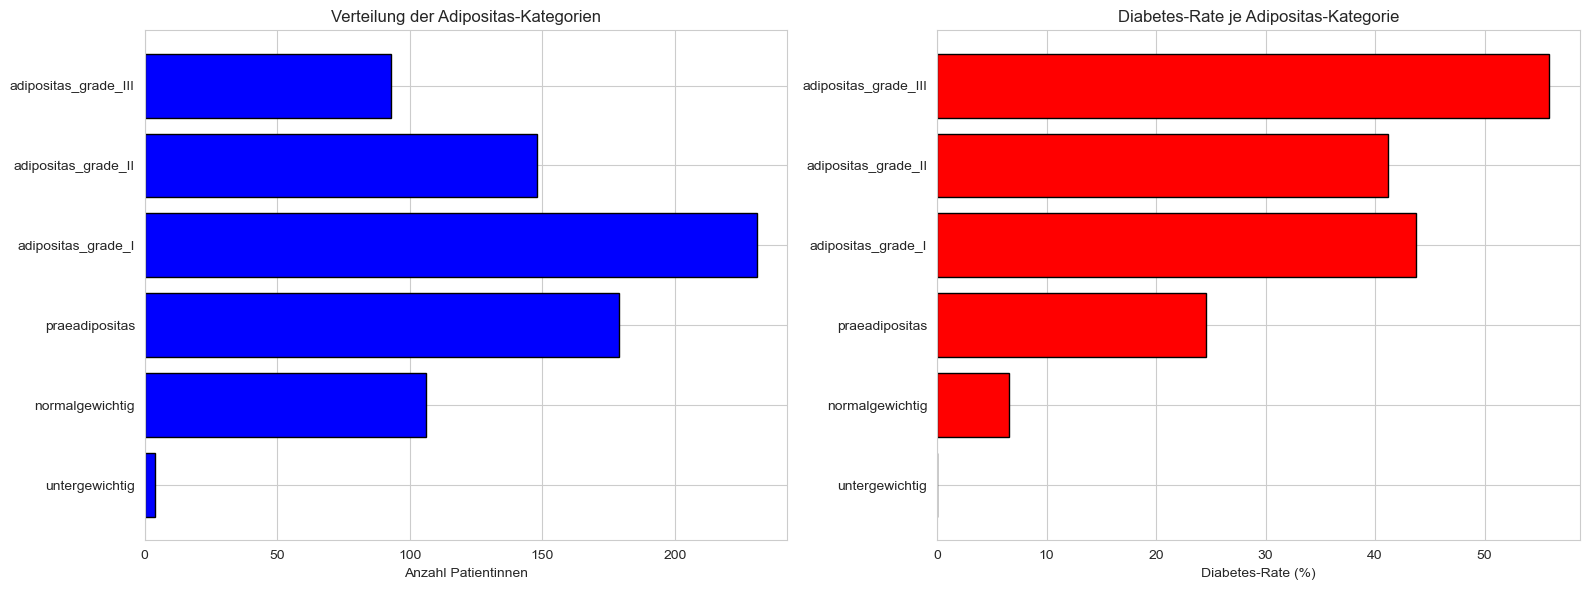

In [6]:

adipositas_order = [
    'untergewichtig', 'normalgewichtig', 'praeadipositas',
    'adipositas_grade_I', 'adipositas_grade_II', 'adipositas_grade_III'
]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Häufigkeit der Adipositas-Kategorien
counts_adip = df['Adipositas'].value_counts().reindex(adipositas_order)

ax[0].barh(range(len(counts_adip)), counts_adip.values, color='blue', edgecolor='black')
ax[0].set_yticks(range(len(counts_adip)))
ax[0].set_yticklabels(adipositas_order)
ax[0].set_xlabel('Anzahl Patientinnen')
ax[0].set_title('Verteilung der Adipositas-Kategorien')

# Plot 2: Diabetes-Rate pro Adipositas-Kategorie
diabetes_rate = df.groupby('Adipositas')['Outcome'].mean().reindex(adipositas_order) * 100
ax[1].barh(range(len(diabetes_rate)), diabetes_rate.values, color='red', edgecolor='black')
ax[1].set_yticks(range(len(diabetes_rate)))
ax[1].set_yticklabels(adipositas_order)
ax[1].set_xlabel('Diabetes-Rate (%)')
ax[1].set_title('Diabetes-Rate je Adipositas-Kategorie')


plt.tight_layout()
fig.savefig("figures/adipositas_verteilung.png", dpi=300, bbox_inches="tight")
plt.show()

Dargestellt sind zwei Säulendiagramme zur Verteilung der Adipositas bzw. zur prozentualen Verteilung der Diabetes-Rate je Adipositas-Kategorie. Der größte Anteil der Patientinnen fällt in die Kategorien Adipositas Grad und Präadipositas. 
Die Diabetes-Rate steigt mit dem BMI. Patientinnen mit Adipositas Grad III haben eine deutlich höhere Diabetes-Prävalenz als Normalgewichtige. Das bestätigt den bekannten klinischen Zusammenhang zwischen Übergewicht und Typ-2-Diabetes. Interessant ist, dass Patientinnen mit einer Adipositas Grad I eine leicht höhere Rate an Diabetes aufweisen als Patientinnen mit Adipositas Grad II.

## Glukose vs. BMI (Streudiagramm)

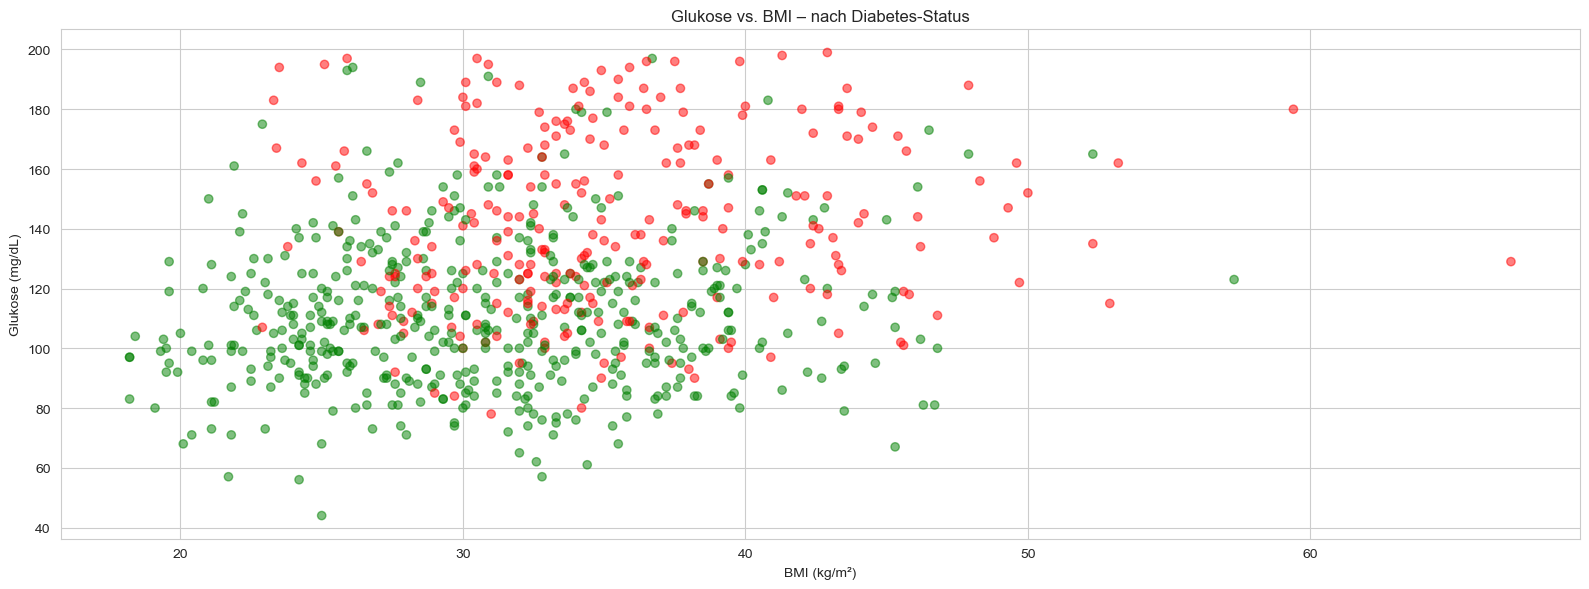

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

colors = ['green' if c == 0 else 'red' for c in df['Outcome']]
scatter = ax.scatter(df['BMI'], df['Glucose'], c=colors, alpha=0.5)

ax.set_xlabel('BMI (kg/m²)')
ax.set_ylabel('Glukose (mg/dL)')
ax.set_title('Glukose vs. BMI – nach Diabetes-Status')

plt.tight_layout()
fig.savefig("figures/scatterplot_Glukose_vs_BMI.png", dpi=300, bbox_inches="tight")
plt.show()


Streudiagramme für die Parameter Serum-Glukose und BMI. Das Streudiagramm zeigt, dass Diabetes-Patientinnen (rot) tendenziell höhere Glukosewerte und einen höheren BMI aufweisen und sich damit im rechten oberen Bereich des Plots konzentrieren. 
Die Korrelation zwischen BMI und Glukose ist zwar nicht stark ausgeprägt, dennoch weißt das Streudiagramm darauf hin, dass das gemeinsame Auftreten von hohem BMI und hohem Glukosewert mit Diabetes assoziiert sind.

## Korrelationen Übersicht

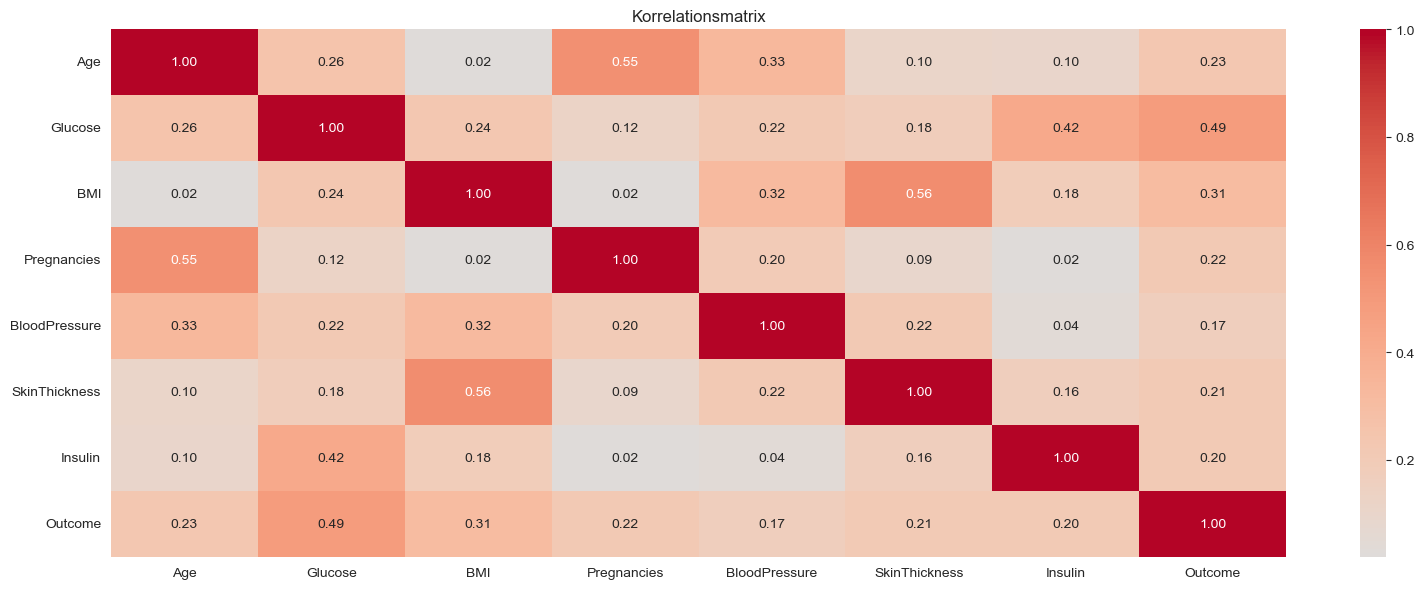

Korrelation mit Outcome:
Outcome          1.000000
Glucose          0.491475
BMI              0.306760
Age              0.233907
Pregnancies      0.219034
SkinThickness    0.207373
Insulin          0.204369
BloodPressure    0.169854
Name: Outcome, dtype: float64


In [8]:
cols = ['Age', 'Glucose', 'BMI', 'Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'Outcome']
corr = df[cols].corr()

plt.figure(figsize=(16, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korrelationsmatrix')

plt.tight_layout()
plt.savefig("figures/korrelationsmatrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Korrelation mit Outcome:")
print(corr['Outcome'].sort_values(ascending=False))




Darstellung der Korrelationsmatrix der wichtigsten Parameter. Bezogen auf das Outcome zeigt die Serum-Glucose die höchste Korrelation (~0.49), gefolgt vom BMI (~0.31) und dem Alter (~0.24). Eine negative Korrelation findet sich nicht. Weitere höhere Korrelation wie zwischen Insulin und Serum-Glucose oder SkinThickness und BMI lassen sich durch die entsprechende Physiologie begründen.

## Schwangerschaft und Diabetes (Streudiagramm)

In [9]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Pregnancies',
    y='Glucose',
    color=df['Outcome'].map({0: 'Kein Diabetes', 1: 'Diabetes'}),
    color_discrete_map={'Kein Diabetes': 'green', 'Diabetes': 'red'},
    labels={'color': 'Diagnose'},
    title='Schwangerschaften vs. Glukose nach Outcome',
)


fig.write_html("figures/interactive_scatterplot_pregnancies_glucose.html") #Speicher als png nicht möglich, da interaktive Elemente enthalten sind
fig.show()

Darstellung eines interaktiven Streudiagramm zwischen Glucose und Schwangerschaft bezogen auf das Outcome. Es wird deutlich, dass bei mehr Schwangerschaften bereits bei einer niedrigeren Serum-Glukose ein Diabetes vorliegen kann.

## Zusammenfassung

In [10]:
print("ERKENNTNISSE – DIABETES DATENSATZ")
print("=" * 50)
print(f"Anzahl Patientinnen:     {len(df)}")
print(f"Diabetes-Prävalenz:      {df['Outcome'].mean()*100:.1f}%")
print()
print("Durchschnittswerte je Gruppe:")
print(df.groupby('Outcome')[['Glucose', 'BMI', 'Age', 'Pregnancies', 'BloodPressure']].mean().round(1).to_string())
print()
print("Stärkste Prädiktoren für Diabetes (Korrelation mit Outcome):")
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
corr_vals = df[num_cols + ['Outcome']].corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print(corr_vals.to_string())


ERKENNTNISSE – DIABETES DATENSATZ
Anzahl Patientinnen:     761
Diabetes-Prävalenz:      34.8%

Durchschnittswerte je Gruppe:
         Glucose   BMI   Age  Pregnancies  BloodPressure
Outcome                                                 
0          110.8  30.9  31.2          3.3           71.1
1          142.1  35.3  37.0          4.9           75.2

Stärkste Prädiktoren für Diabetes (Korrelation mit Outcome):
Glucose                     0.491475
BMI                         0.306760
Age                         0.233907
Pregnancies                 0.219034
SkinThickness               0.207373
Insulin                     0.204369
DiabetesPedigreeFunction    0.173897
BloodPressure               0.169854


Erkenntnisse:
Bezogen auf die einzelnen Parameter ist Glukose der stärkste Prädiktor. Patientinnen mit Diabetes haben im Schnitt einen Glukosewert von ~141 mg/dL, ohne Diabetes ~110 mg/dL. Das ist der deutlichste Unterschied zwischen den beiden Gruppen.
BMI und Adipositas spielen eine weitere Rolle. Die Diabetes-Rate steigt mit jeder Adipositas-Kategorie an. Der Großteil der Patientinnen ist übergewichtig, nur wenige sind normalgewichtig. Interessant ist eine Quasi-Überstimmung der Diabetes-Quote zwischen Adipositas Grad I und II.
Ältere Patientinnen erkranken häufiger. Diabetes-Patientinnen sind im Schnitt ~37 Jahre alt, die gesunde Gruppe ~31 Jahre. Zusätzlich erkranken Patientinnen, welche viele Schwangerschaften hatten, tendenziell häufiger an Diabetes. Eine Erklärung hierfür bietet eventuell das Krankheitsbild der Gestationsdiabetes.
Der Blutdruck ist kein starkes Unterscheidungsmerkmal. Der Unterschied zwischen den beiden Gruppen ist gering, der Blutdruck allein sagt also wenig über den Diabetes-Status aus.
Der Datensatz ist mit ca. 35% Diabetes-Erkrankten unbalanciert.